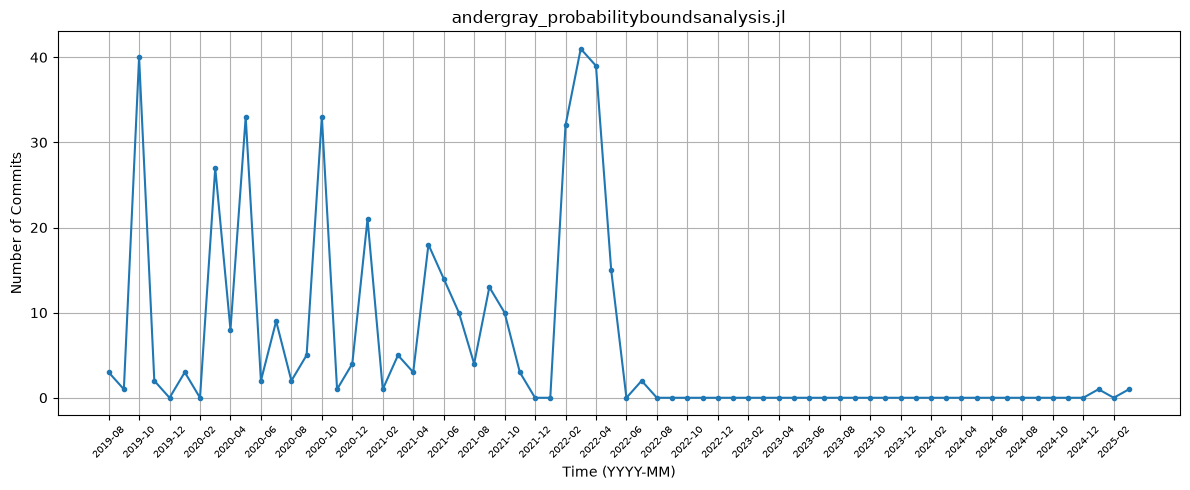

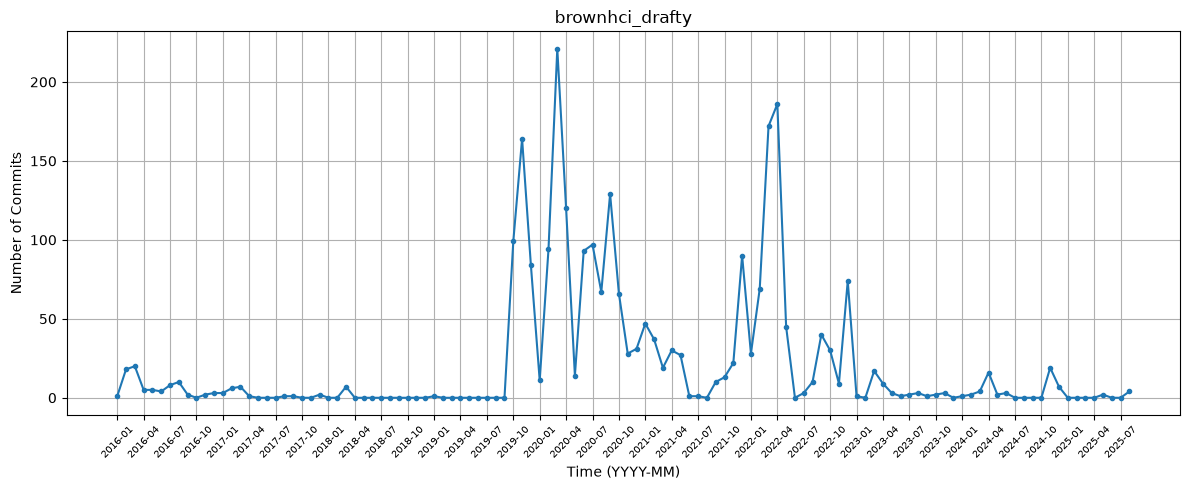

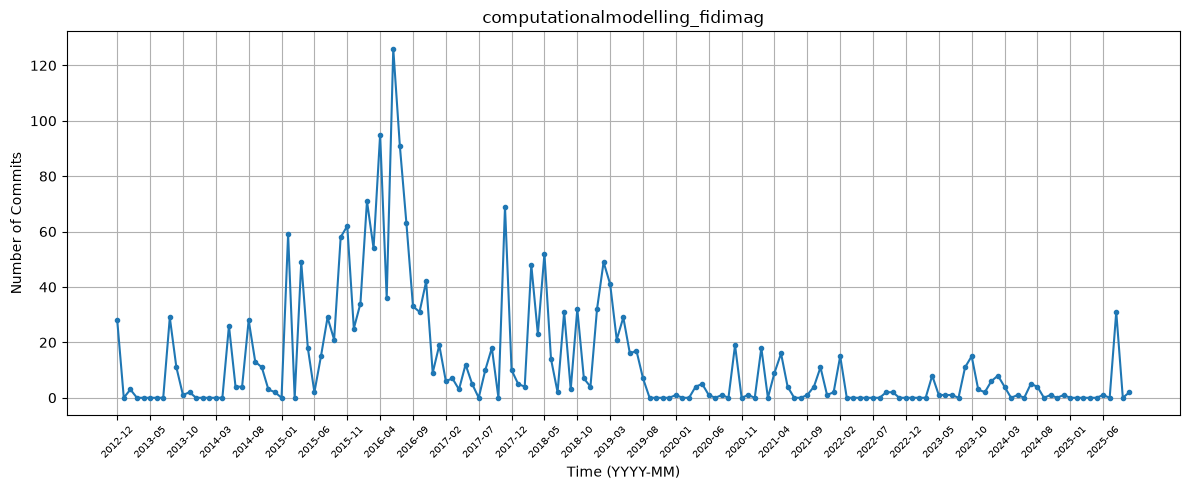

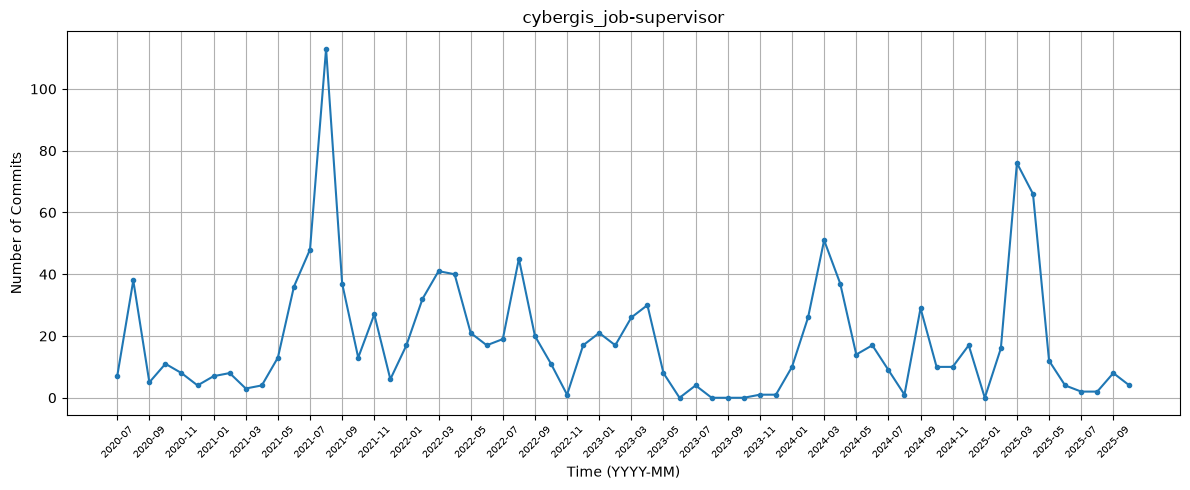

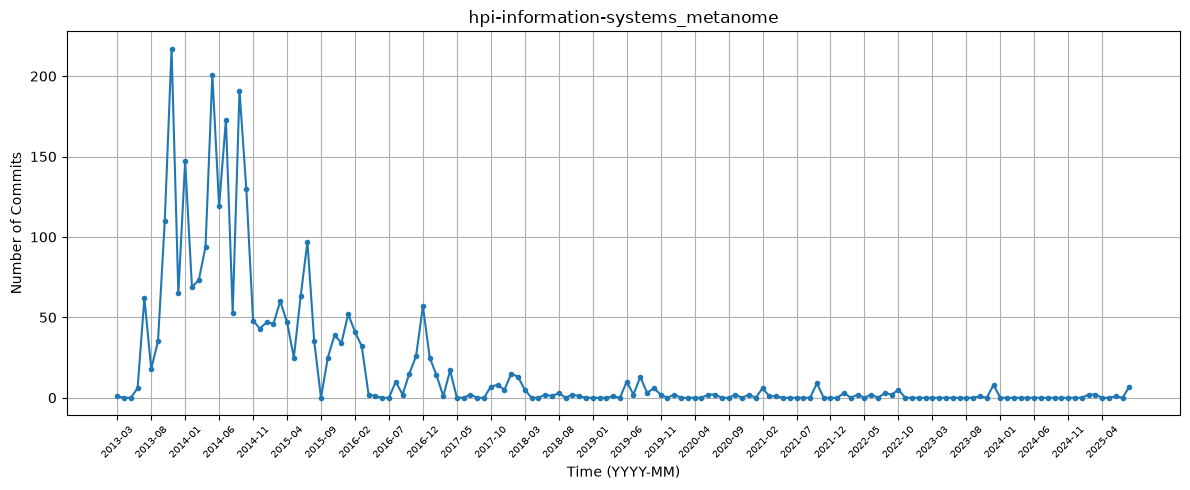

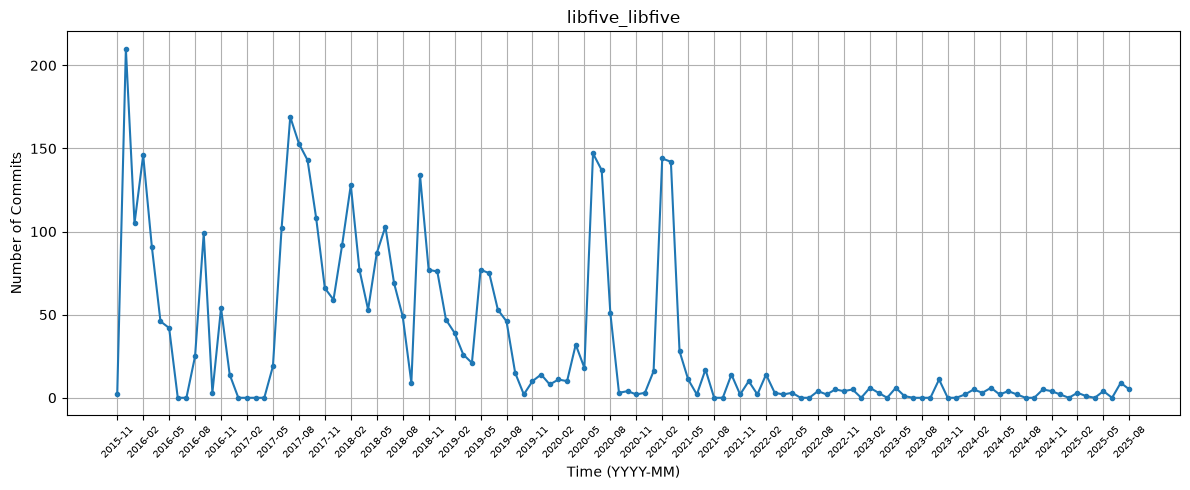

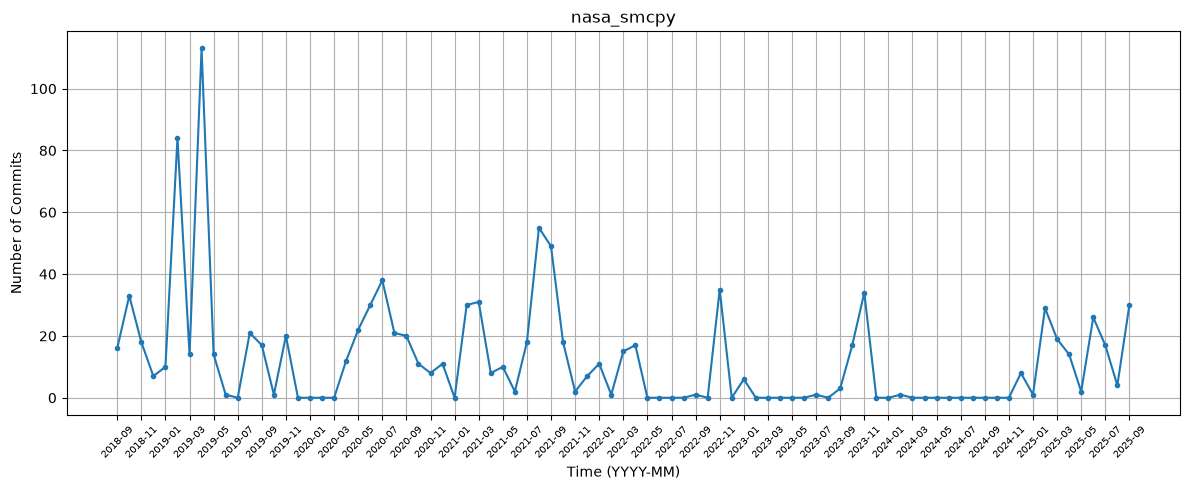

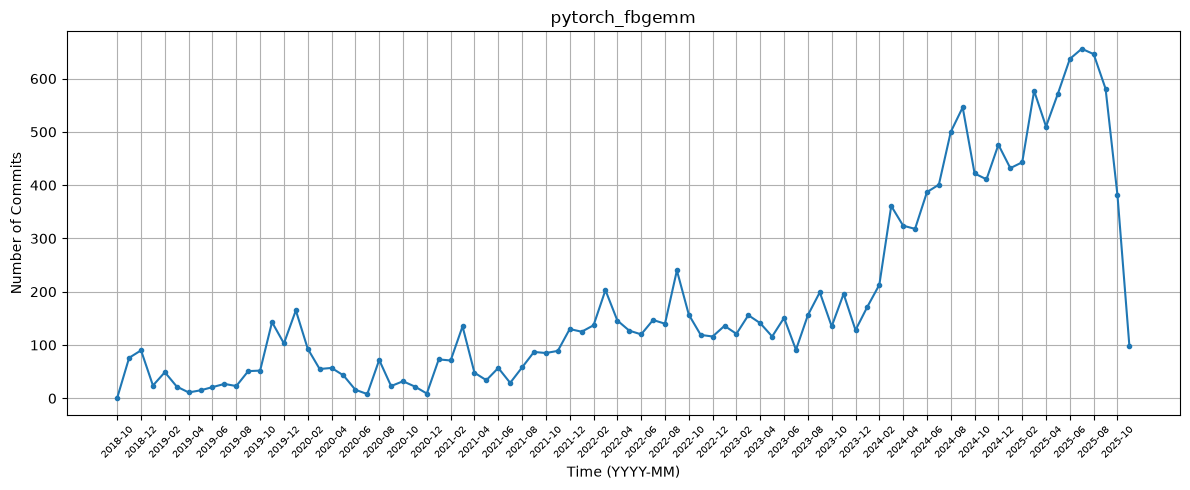

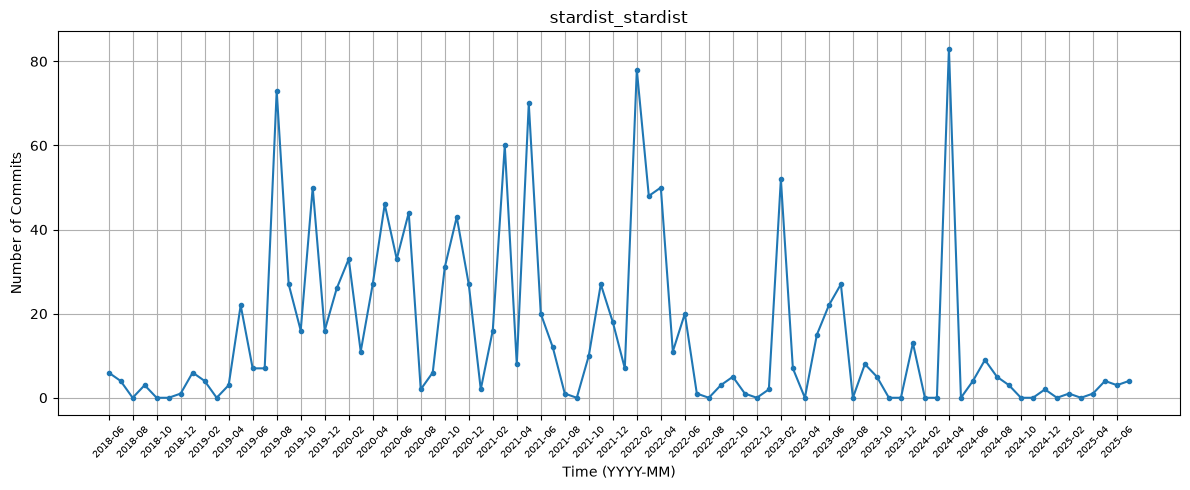

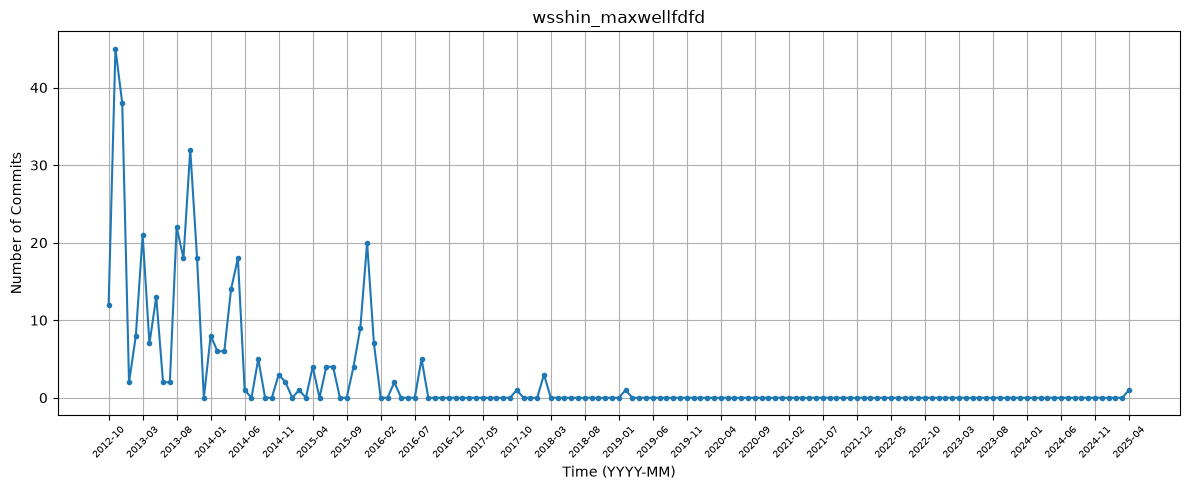

,project,LongestGapStart (YYYY-MM),LongestGapEnd (YYYY-MM),LongestGapLength (months),NumCommitsAfterLastGap,NumberOfGapsInTimeline
0,andergray_probabilityboundsanalysis.jl,2022-08,2024-12,29,2,1
1,brownhci_drafty,2018-04,2018-12,9,2384,5
2,computationalmodelling_fidimag,2022-03,2022-08,6,110,6
3,cybergis_job-supervisor,2023-08,2023-10,3,423,1
4,hpi-information-systems_metanome,2024-01,2025-01,13,12,6
5,libfive_libfive,2017-01,2017-04,4,3138,2
6,nasa_smcpy,2024-03,2024-11,9,150,4
7,pytorch_fbgemm,N/A,N/A,0,N/A,0
8,stardist_stardist,2018-10,2018-11,2,1299,0
9,wsshin_maxwellfdfd,2019-03,2025-03,73,1,5


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

netid = 'hcrettol'

# load the commits from part 1
df = pd.read_csv(netid + '_project_summary.csv', sep=';', header=None,
                 names=['project', 'commit', 'author', 'time', 'message'])
df['Month'] = pd.to_datetime(df['time'], unit='s').dt.to_period('M')

rows = []
for prj in sorted(df['project'].unique()):
    # count commits per month, and fill in the months with 0 commits
    counts = df[df['project'] == prj].groupby('Month').size()
    all_months = pd.period_range(counts.index.min(), counts.index.max(), freq='M')
    counts = counts.reindex(all_months, fill_value=0)

    ts = pd.DataFrame({'Month': counts.index.astype(str), '#Commits': counts.values})
    ts.to_csv(f'{netid}_commits_timeseries_{prj}.csv', sep=';', index=False)

    # plot it
    plt.figure(figsize=(12, 5))
    plt.plot(ts['Month'], ts['#Commits'], marker='o', markersize=3, linestyle='-')
    plt.xlabel('Time (YYYY-MM)')
    plt.ylabel('Number of Commits')
    plt.title(prj)
    plt.grid(True)
    step = max(1, len(ts) // 30)   # don't show every month or the labels pile up
    plt.xticks(range(0, len(ts), step), ts['Month'][::step], rotation=45, fontsize=7)
    plt.tight_layout()
    plt.savefig(f'{netid}_timeseries_{prj}.png', dpi=300)
    plt.show()
    plt.close()

    # find the longest stretch of months with 0 commits, and count gaps of 3+ months
    best_len, best_start, best_end = 0, None, None
    num_gaps = 0
    run_len, run_start = 0, None
    for i, c in enumerate(ts['#Commits']):
        if c == 0:
            if run_len == 0:
                run_start = i
            run_len += 1
        if c != 0 or i == len(ts) - 1:
            if run_len >= 3:
                num_gaps += 1
            if run_len > best_len:
                best_len, best_start, best_end = run_len, run_start, run_start + run_len - 1
            run_len = 0

    if best_len > 0:
        gap_start = ts['Month'][best_start]
        gap_end = ts['Month'][best_end]
        after = ts['#Commits'][best_end + 1:].sum()
    else:
        gap_start, gap_end, after = 'N/A', 'N/A', 'N/A'

    rows.append({'project': prj,
                 'LongestGapStart (YYYY-MM)': gap_start,
                 'LongestGapEnd (YYYY-MM)': gap_end,
                 'LongestGapLength (months)': best_len,
                 'NumCommitsAfterLastGap': after,
                 'NumberOfGapsInTimeline': num_gaps})

gaps = pd.DataFrame(rows)
gaps

# Interpretation

| Project | Activity Pattern | Gaps (3+ months) |
|---|---|---|
| andergray_probabilityboundsanalysis.jl | declining | 1 |
| brownhci_drafty | irregular | 5 |
| computationalmodelling_fidimag | declining | 6 |
| cybergis_job-supervisor | cyclical | 1 |
| hpi-information-systems_metanome | declining | 6 |
| libfive_libfive | declining | 2 |
| nasa_smcpy | irregular | 4 |
| pytorch_fbgemm | rising | 0 |
| stardist_stardist | irregular | 0 |
| wsshin_maxwellfdfd | declining | 5 |

Most of my projects ended up being declining. andergray, fidimag, metanome, libfive, and maxwellfdfd all had a lot of commits early on and then slowed down a lot. My guess is the main developers moved on to other things or the software was mostly finished and only needed small fixes after that. maxwellfdfd was the biggest example of this, with a 73 month gap from 2019-03 to 2025-03 and only 1 commit after it. andergray was similar with a 29 month gap and only 2 commits after.

fbgemm was the only rising project, and it never had a month with zero commits. That makes sense since it's part of PyTorch and Meta has a whole team working on it. The big drop at the very end is just because the data stops partway through the last month.

job-supervisor looked cyclical to me since it has bursts of activity about once a year with slower months in between. Since it's an academic project, it might follow a school or grant schedule.

drafty, smcpy, and stardist were irregular. Their activity goes up and down a lot without any real pattern, so it seems like people just work on them whenever they have time or need something specific.

In [2]:
# get the 10 commits before and after the longest gap for each project
df = df.sort_values('time')
parts = []
for _, g in gaps.iterrows():
    prj = g['project']
    if g['LongestGapStart (YYYY-MM)'] == 'N/A':   # fbgemm never had a gap, so skip it
        continue
    start = pd.Period(g['LongestGapStart (YYYY-MM)'], freq='M')
    end = pd.Period(g['LongestGapEnd (YYYY-MM)'], freq='M')
    p = df[df['project'] == prj]
    before = p[p['Month'] < start].tail(10).copy()
    after = p[p['Month'] > end].head(10).copy()
    before.insert(0, 'pre/post', 'pre')
    after.insert(0, 'pre/post', 'post')
    parts += [before, after]

gap_commits = pd.concat(parts)[['pre/post', 'project', 'commit', 'author', 'time', 'message']]
gap_commits.to_csv(netid + '_project_gap_commits.csv', sep=';', index=False, header=False)
print('Saved', len(gap_commits), 'commits')

# show the messages so we can pick themes
for _, r in gap_commits.iterrows():
    msg = str(r['message']).strip().replace('\n', ' ')[:100]
    print(r['pre/post'], '|', r['project'], '|', msg)

Saved 163 commits
pre | andergray_probabilityboundsanalysis.jl | Merge pull request #39 from AnderGray/new_interpolation  New interpolation
pre | andergray_probabilityboundsanalysis.jl | build based on cf16a4c
pre | andergray_probabilityboundsanalysis.jl | Update Project.toml
pre | andergray_probabilityboundsanalysis.jl | build based on bef1767
pre | andergray_probabilityboundsanalysis.jl | Update special.jl
pre | andergray_probabilityboundsanalysis.jl | Update Project.toml
pre | andergray_probabilityboundsanalysis.jl | Merge pull request #40 from schillic/patch-1  Replace auxiliary method outsourced to IntervalArithme
pre | andergray_probabilityboundsanalysis.jl | build based on 319712b
pre | andergray_probabilityboundsanalysis.jl | CompatHelper: bump compat for "Interpolations" to "0.14"
pre | andergray_probabilityboundsanalysis.jl | Merge 0a41782ed3f1044737eae33d1ec2e90ee1275789 into 319712bd5a7bc58bbab546b6f311a4efab306419
post | andergray_probabilityboundsanalysis.jl | Update READ

# Gap Commit Themes

| Project | Before Gap | After Gap |
|---|---|---|
| andergray_probabilityboundsanalysis.jl | Automated bot contributions:Dependency updates | Documentation updates:Automated bot contributions |
| brownhci_drafty | Bug fixes:Other | Documentation updates:Other |
| computationalmodelling_fidimag | Other:Dependency updates | Feature development:Documentation updates |
| cybergis_job-supervisor | Bug fixes:Automated bot contributions | Bug fixes:Feature development |
| hpi-information-systems_metanome | Automated bot contributions:Dependency updates | Feature development:Automated bot contributions |
| libfive_libfive | Feature development:Bug fixes | Feature development:Other |
| nasa_smcpy | Feature development:Bug fixes | Feature development:Bug fixes |
| pytorch_fbgemm | N/A | N/A |
| stardist_stardist | Documentation updates:Release | Bug fixes:Feature development |
| wsshin_maxwellfdfd | Bug fixes:Documentation updates | Bug fixes:N/A |

pytorch_fbgemm never had a month with zero commits, so it has no gap. wsshin_maxwellfdfd only has 1 commit after its gap, so it only gets one theme.